In [38]:
%load_ext autoreload
%autoreload 2
    
import datetime
import os
import ee
import geemap
import joblib
import matplotlib.pyplot as plt
import torch
import numpy as np

from identify_locations import identify_forests, identify_route_buffer
from read_and_process_hls import compute_hls_indices
from fit_greendown_curves import compute_transition_dates, compute_average_transition_dates
from filter_ci_widths import count_narrow_ci_pixel_years
from build_data_table import build_feature_table, export_prediction_avg_assets
from edit_data_table import edit_feature_table
from plot_feature_distributions import plot_feature_distributions
from decision_trees import split_data, fit_tree, plot_decision_tree, evaluate_decision_tree
from gridmet_utils import fetch_gridmet_cdd_historical
from constants import DATA_DIR, GREENDOWN_DIR, MODEL_DIR

from rnn_model import (
    RNN_FEATURE_COLS, RNNPhenologyModel,
    build_rnn_sequences, compute_rnn_norm_stats, normalize_sequences,
    split_sequences, oversample_sequences, train_rnn, evaluate_rnn, save_rnn_model,
    plot_rnn_training_curves
)

ee.Initialize(project='turnkey-lacing-391919')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(GREENDOWN_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

ma_forest    = identify_forests()
route_buffer = identify_route_buffer()

start_year    = 2013 #2013  # First HLS year
download_year = 2025  # Last year to download (includes 2025 for prediction)
train_year    = 2024  # Last year included in model training

refit_models = True

In [3]:

# ----------------------------
# Fit logistic curves for each year (download all years including 2025)
# ----------------------------
all_year_paths = []
for y in range(start_year, download_year + 1):
    print(f'Processing {y}...')
    hls   = compute_hls_indices(route_buffer, ma_forest, y)
    paths = compute_transition_dates(hls, route_buffer, ma_forest, y, data_dir=DATA_DIR, greendown_dir=GREENDOWN_DIR)
    all_year_paths.append(paths)

prev_year_paths = all_year_paths[-1]   # most recent year

# ----------------------------
# Average transition dates across all years
# ----------------------------
print('Computing averages...')
avg_paths = compute_average_transition_dates(all_year_paths, data_dir=DATA_DIR, greendown_dir=GREENDOWN_DIR)

# ----------------------------
# Export committed assets the live (Action) prediction needs for
# doy_minus_avg_middle: the CI-filtered per-pixel cross-year average and the
# global gap-fill scalar. Re-run on every retrain, then commit:
#   greendown_middle_avg_filtered.tif, greendown_avg_meta.json
# ----------------------------
print('\nExporting prediction average assets...')
export_prediction_avg_assets(DATA_DIR, GREENDOWN_DIR)

# ----------------------------
# Filter: pixels with CI width < 15 days for all transitions
# ----------------------------
print('\nFiltering pixel-years by CI width...')
years = list(range(start_year, download_year + 1))
count_narrow_ci_pixel_years(GREENDOWN_DIR, years)

Processing 2013...
  Using cached results for 2013
Processing 2014...
  Using cached results for 2014
Processing 2015...
  Using cached results for 2015
Processing 2016...
  Using cached results for 2016
Processing 2017...
  Using cached results for 2017
Processing 2018...
  Using cached results for 2018
Processing 2019...
  Using cached results for 2019
Processing 2020...
  Using cached results for 2020
Processing 2021...
  Using cached results for 2021
Processing 2022...
  Using cached results for 2022
Processing 2023...
  Using cached results for 2023
Processing 2024...
  Using cached results for 2024
Processing 2025...
  Using cached results for 2025
Computing averages...


/Users/Kathryn/Documents/Professional Development/Google Earth Engine/AppTrail_Phenology/fit_greendown_curves.py:591: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(np.stack(arrays, axis=0), axis=0).astype(np.float32)



Exporting prediction average assets...
  Wrote ./Greendown_Outputs/greendown_middle_avg_filtered.tif (9234 valid pixels)
  Wrote ./Greendown_Outputs/greendown_avg_meta.json (global_avg_middle = 278.17)

Filtering pixel-years by CI width...
  2013: 615 pixels (all phases)  |  start: 623  middle: 878  end: 622
  2014: 236 pixels (all phases)  |  start: 272  middle: 923  end: 244
  2015: 405 pixels (all phases)  |  start: 484  middle: 2261  end: 483
  2016: 284 pixels (all phases)  |  start: 290  middle: 434  end: 288
  2017: 178 pixels (all phases)  |  start: 201  middle: 593  end: 191
  2018: 921 pixels (all phases)  |  start: 928  middle: 1245  end: 932
  2019: 157 pixels (all phases)  |  start: 181  middle: 614  end: 186
  2020: 157 pixels (all phases)  |  start: 173  middle: 297  end: 166
  2021: 432 pixels (all phases)  |  start: 451  middle: 788  end: 456
  2022: 431 pixels (all phases)  |  start: 520  middle: 1410  end: 544
  2023: 489 pixels (all phases)  |  start: 669  middle: 

5066

Prepare Data


  gridMET CDD for 2013 already cached at ./Data/gridmet_cdd_2013.npz
  gridMET CDD for 2014 already cached at ./Data/gridmet_cdd_2014.npz
  gridMET CDD for 2015 already cached at ./Data/gridmet_cdd_2015.npz
  gridMET CDD for 2016 already cached at ./Data/gridmet_cdd_2016.npz
  gridMET CDD for 2017 already cached at ./Data/gridmet_cdd_2017.npz
  gridMET CDD for 2018 already cached at ./Data/gridmet_cdd_2018.npz
  gridMET CDD for 2019 already cached at ./Data/gridmet_cdd_2019.npz
  gridMET CDD for 2020 already cached at ./Data/gridmet_cdd_2020.npz
  gridMET CDD for 2021 already cached at ./Data/gridmet_cdd_2021.npz
  gridMET CDD for 2022 already cached at ./Data/gridmet_cdd_2022.npz
  gridMET CDD for 2023 already cached at ./Data/gridmet_cdd_2023.npz
  gridMET CDD for 2024 already cached at ./Data/gridmet_cdd_2024.npz

Building labeled feature table...
  2013: 615 qualifying pixels
  2014: 236 qualifying pixels
  2015: 405 qualifying pixels
  2016: 284 qualifying pixels
  2017: 178 qual

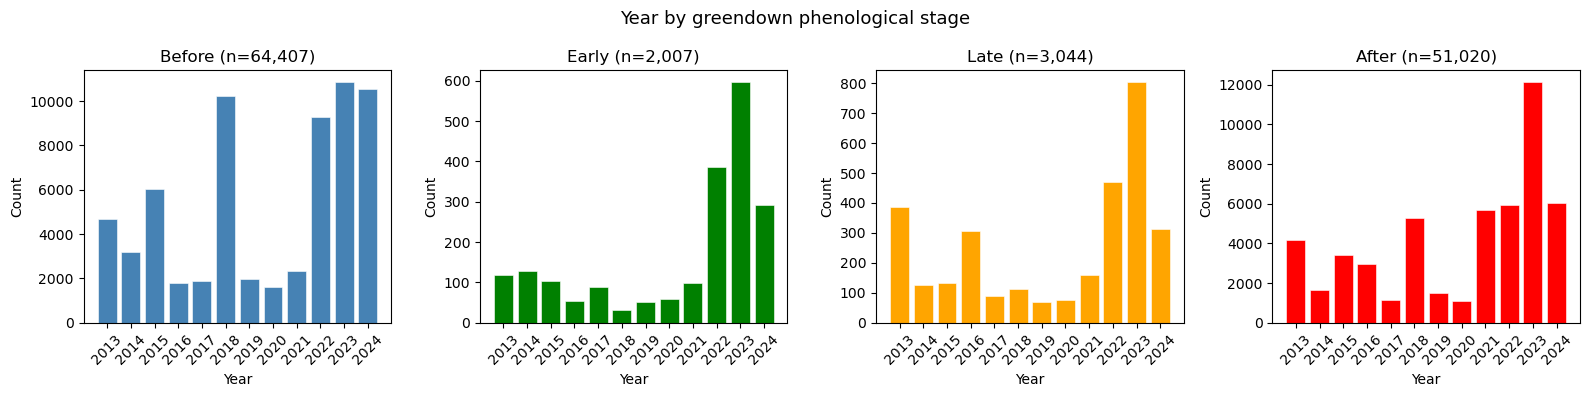

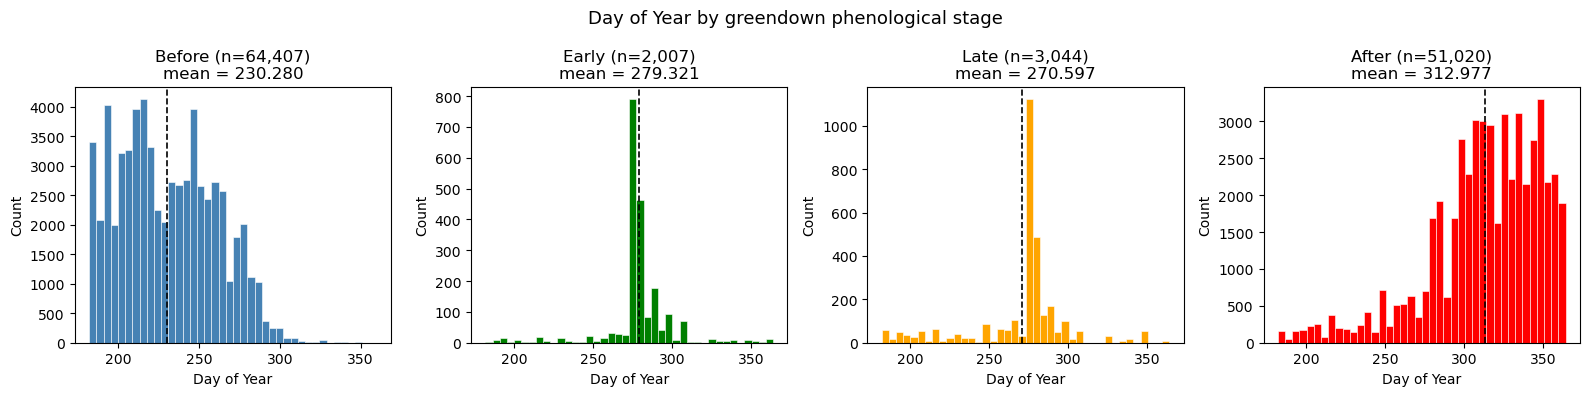

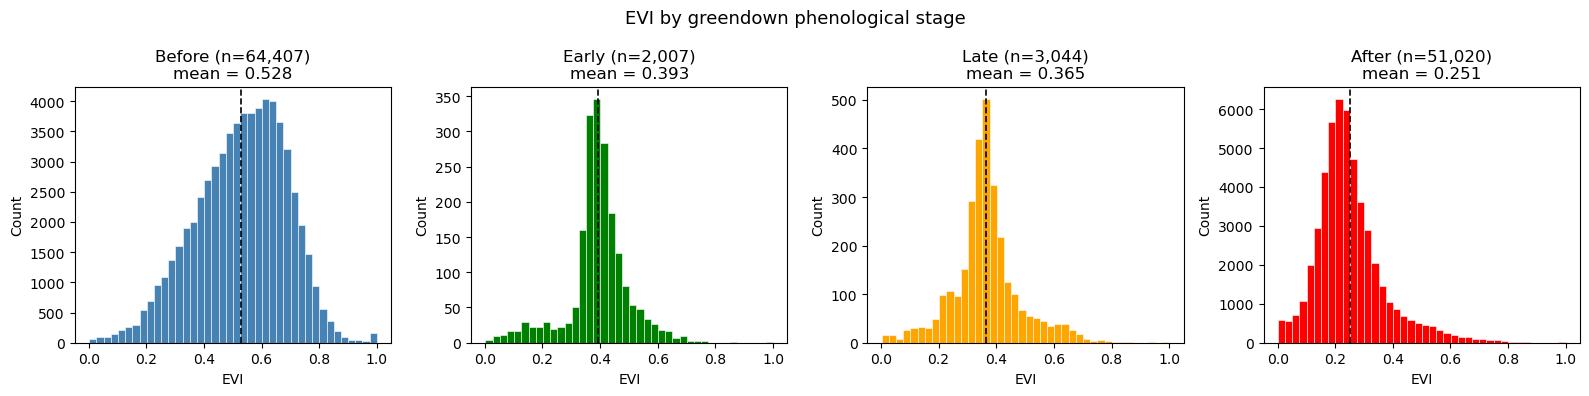

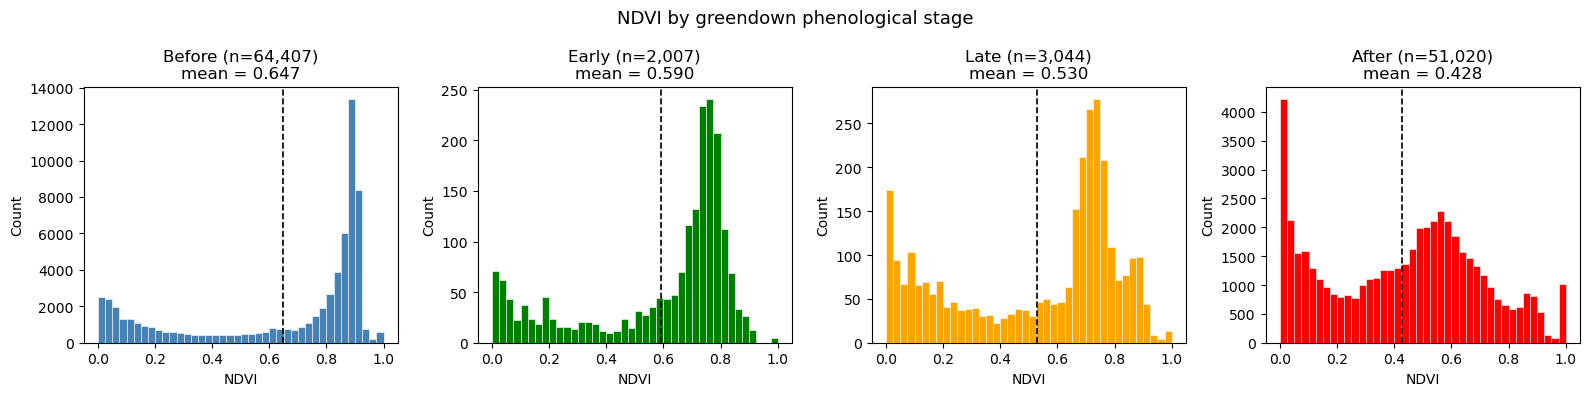

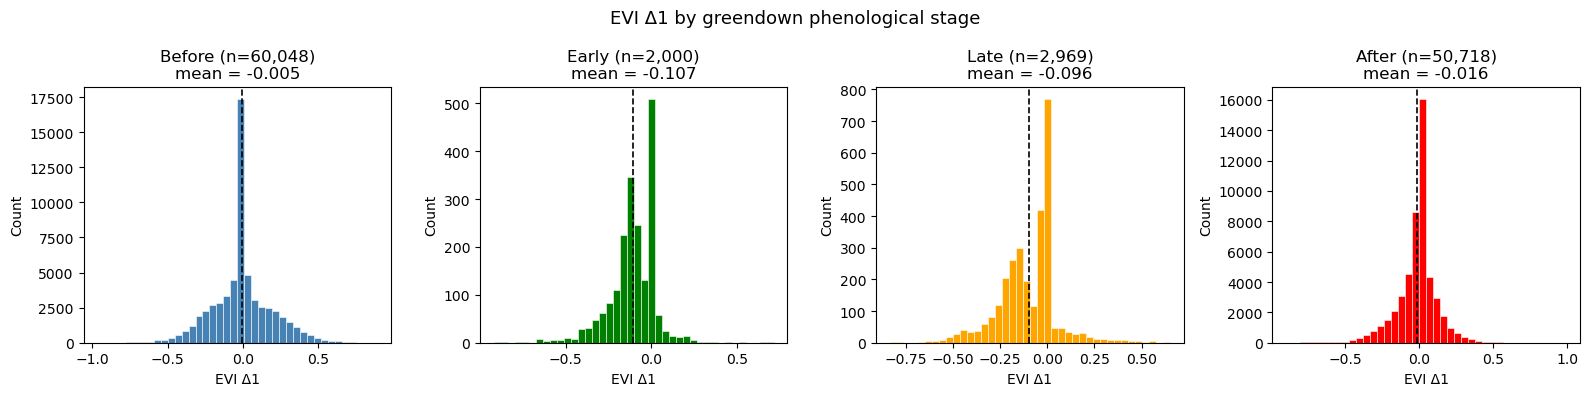

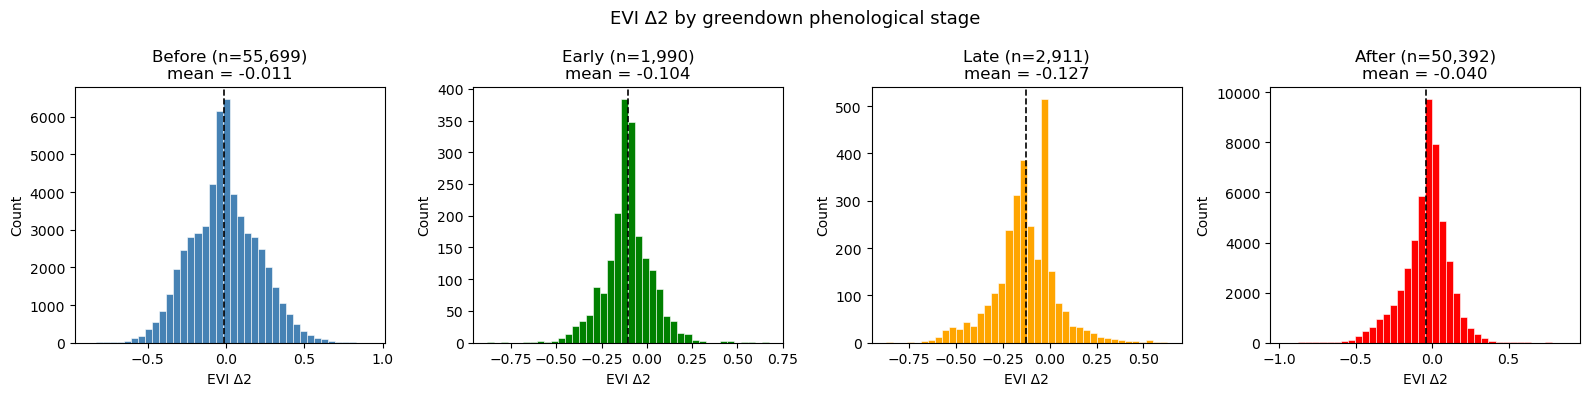

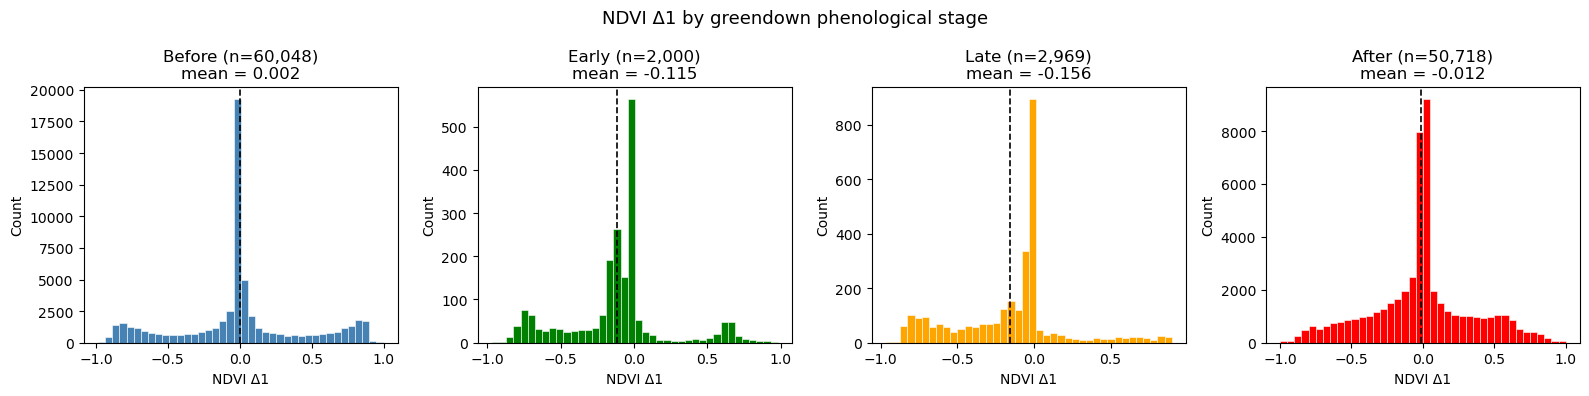

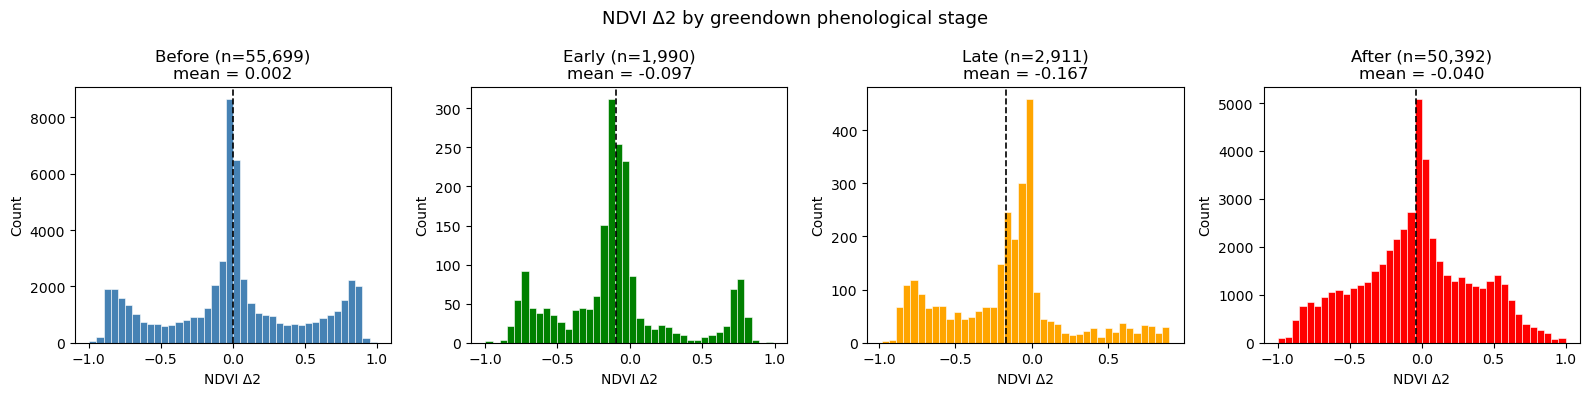

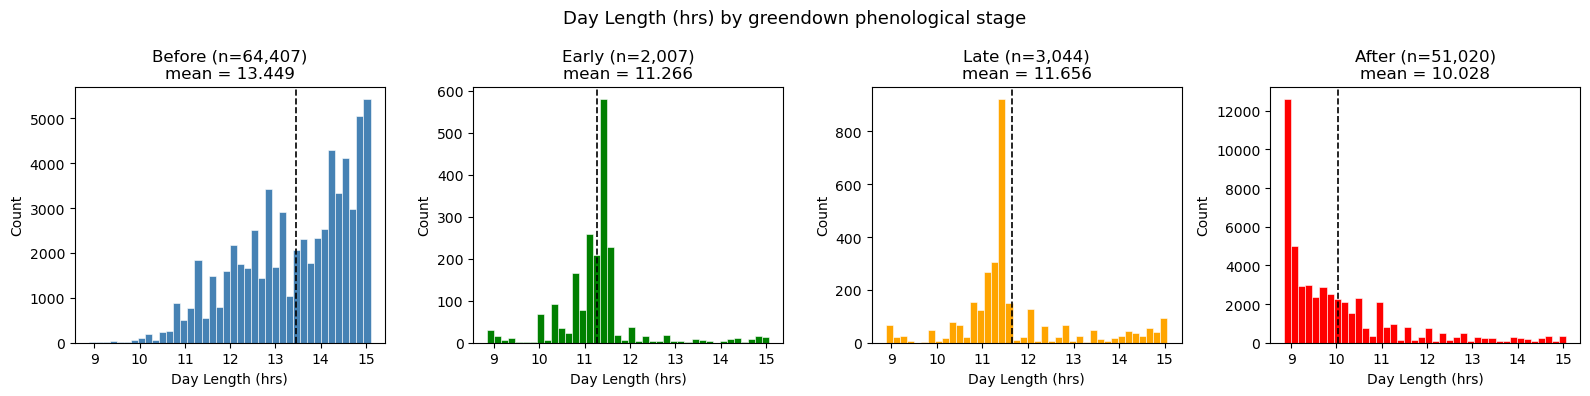

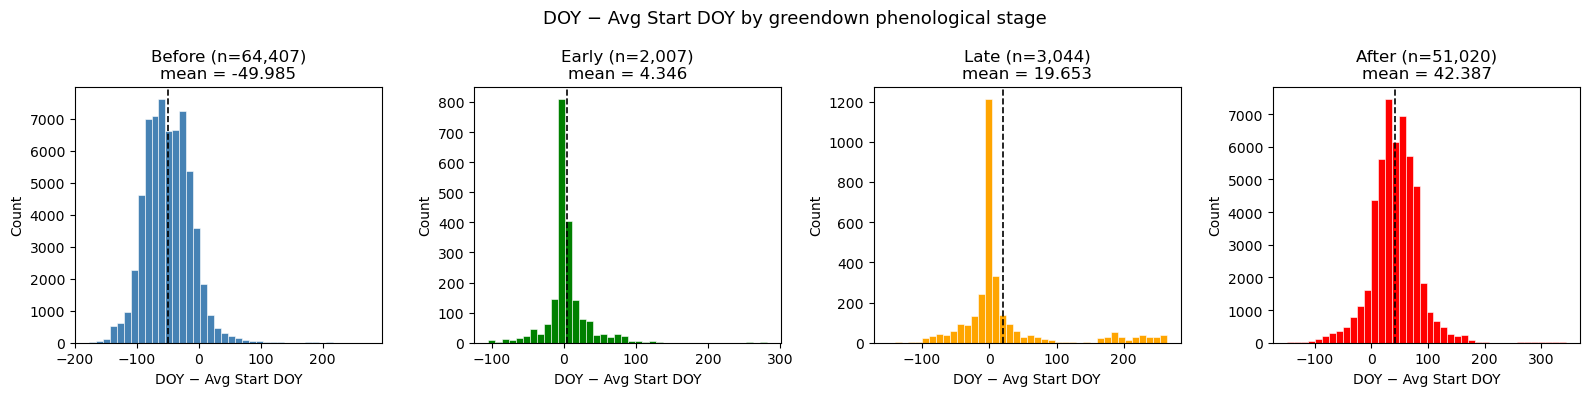

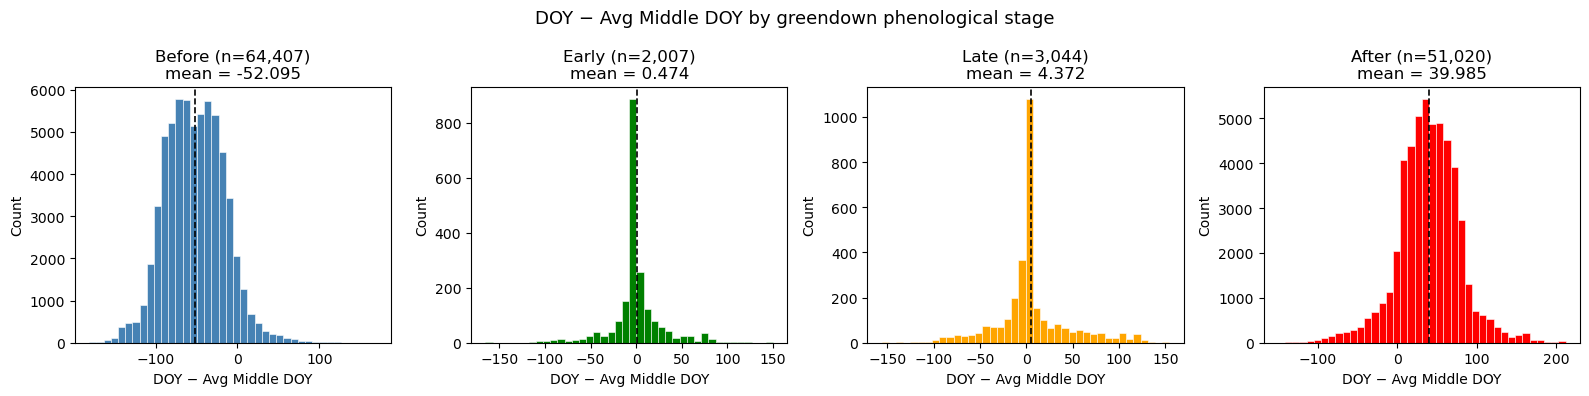

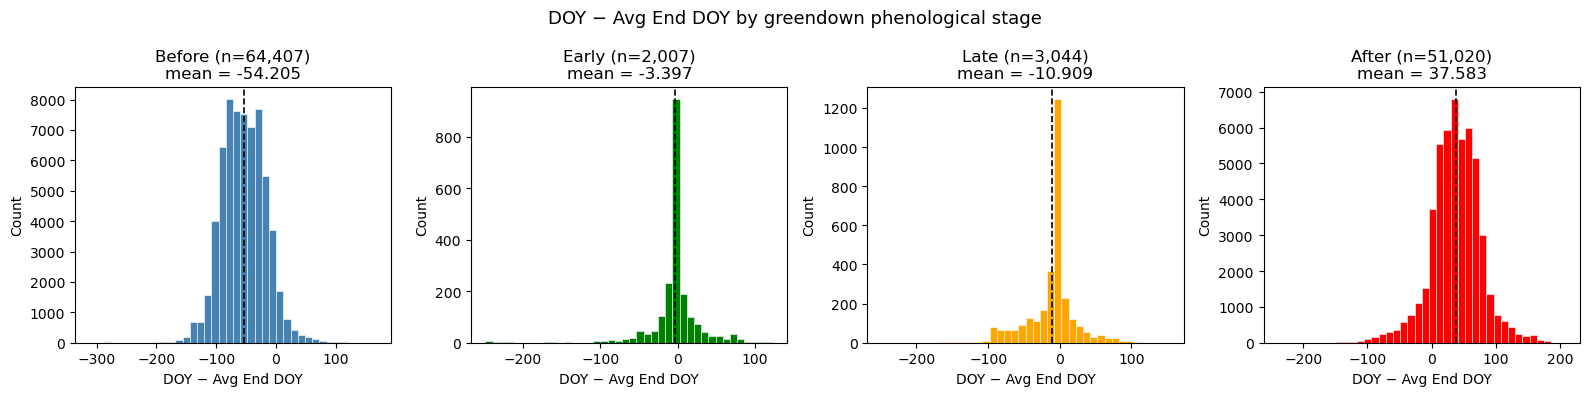

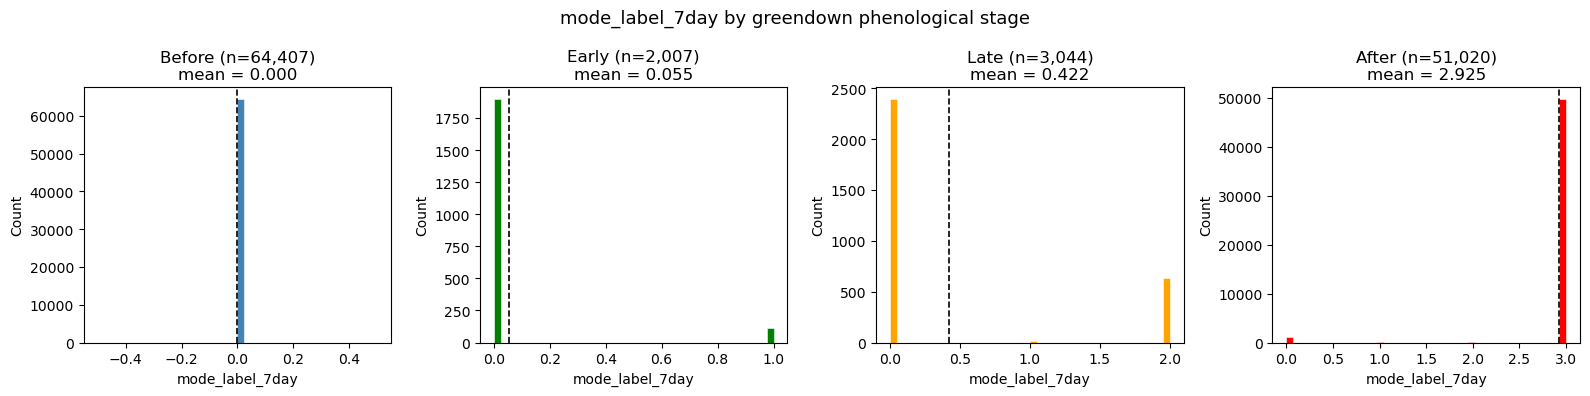

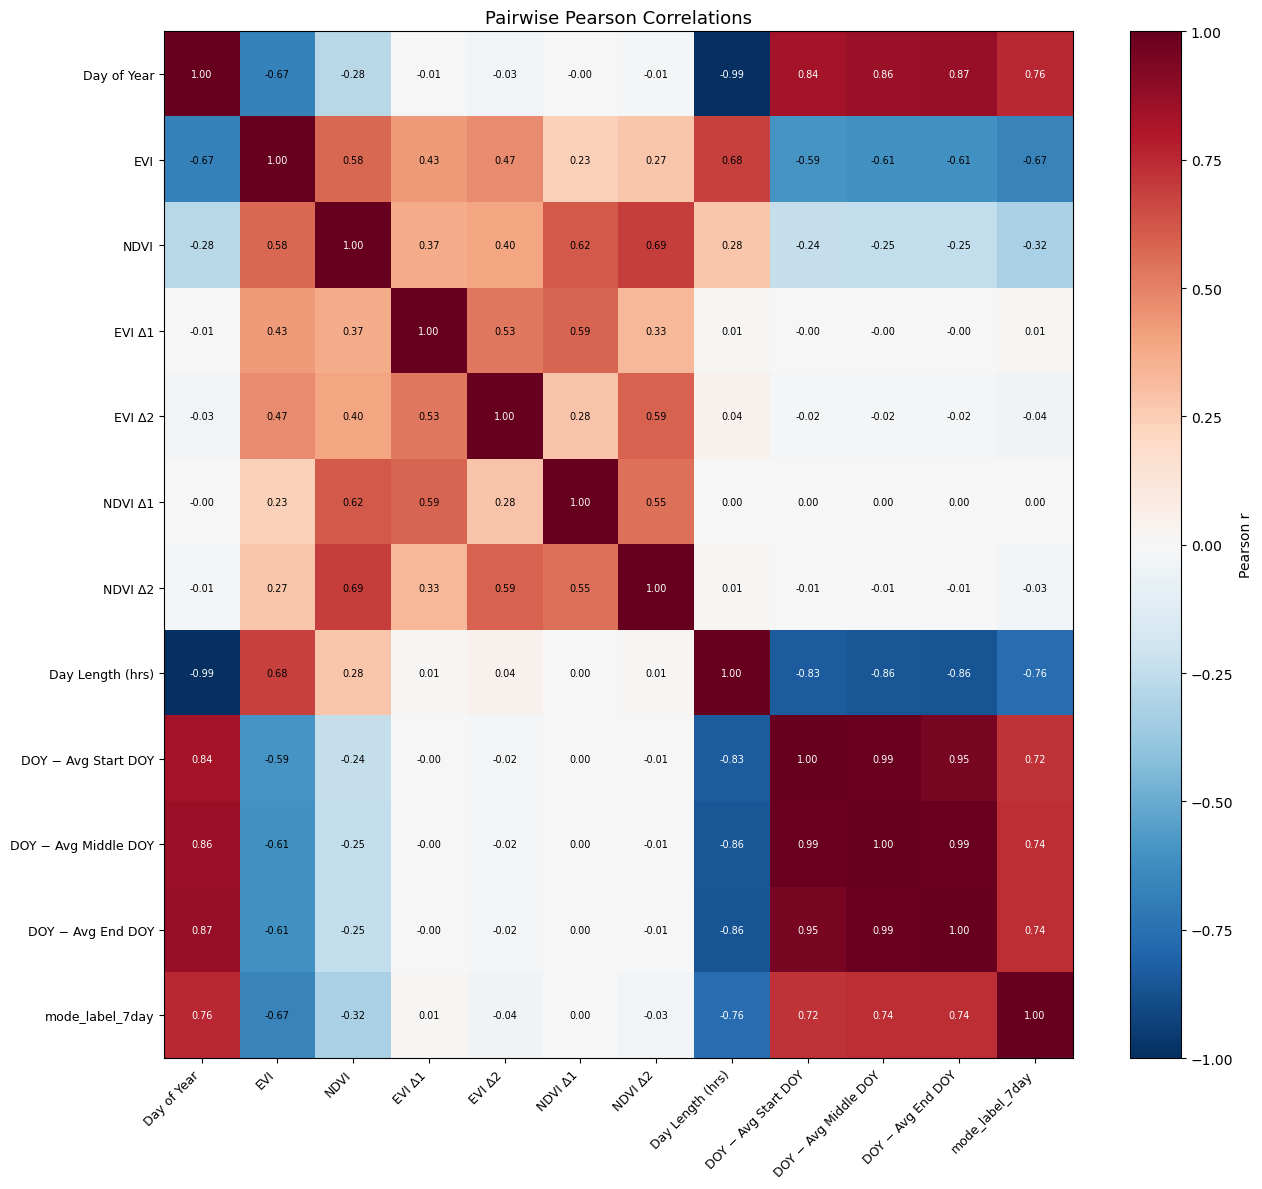

  Dropped 9486 rows with NaN delta values (7.9% of rows)

Edited feature dataframe head after editing:
             EVI      NDVI  evi_delta  evi_delta2  ndvi_delta  ndvi_delta2  \
19234  -0.674591 -1.467371  -1.604065   -1.400391   -1.790860    -1.590241   
20807  -1.060442 -0.278773   0.358285    0.020169    0.198184     0.624627   
120181 -1.370338 -1.589531   0.278427    0.256305    0.040785     0.034584   
81380  -1.839602 -1.776386   0.405704   -0.390188    0.203591    -0.140445   
16665  -0.888764  0.148256   0.834659    0.263257    0.755475     0.573595   

        day_length_hrs  doy_minus_avg_middle  mode_label_7day  label  
19234        -0.346063              0.063573         0.129117  after  
20807        -1.190107              0.780220         1.670002  after  
120181       -1.558975              1.721720         1.670002  after  
81380        -1.556892              1.425496         1.670002  after  
16665        -1.382764              2.088608        -0.641326  after  

N

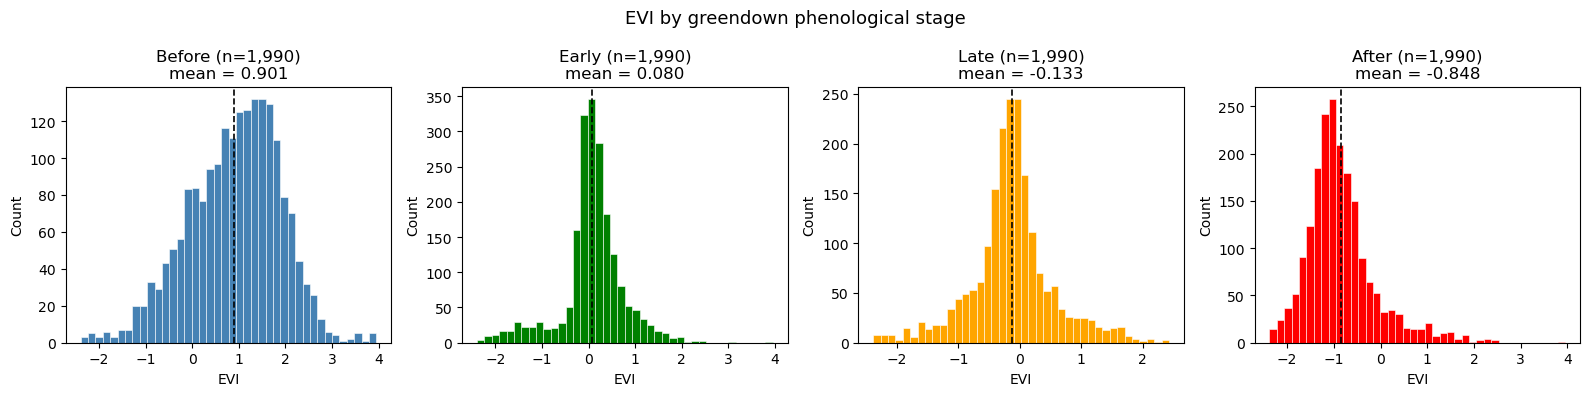

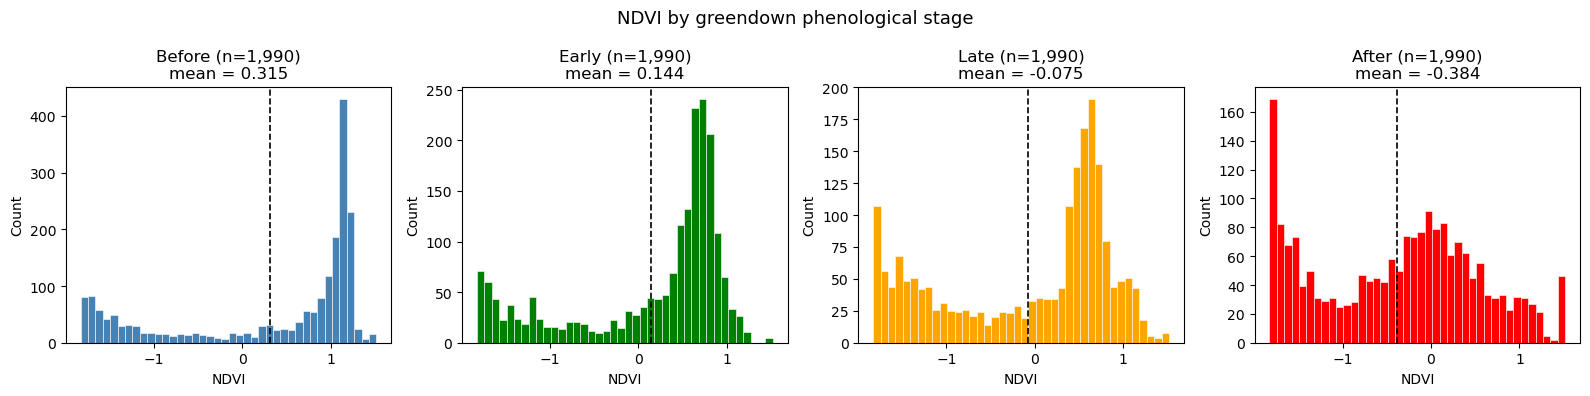

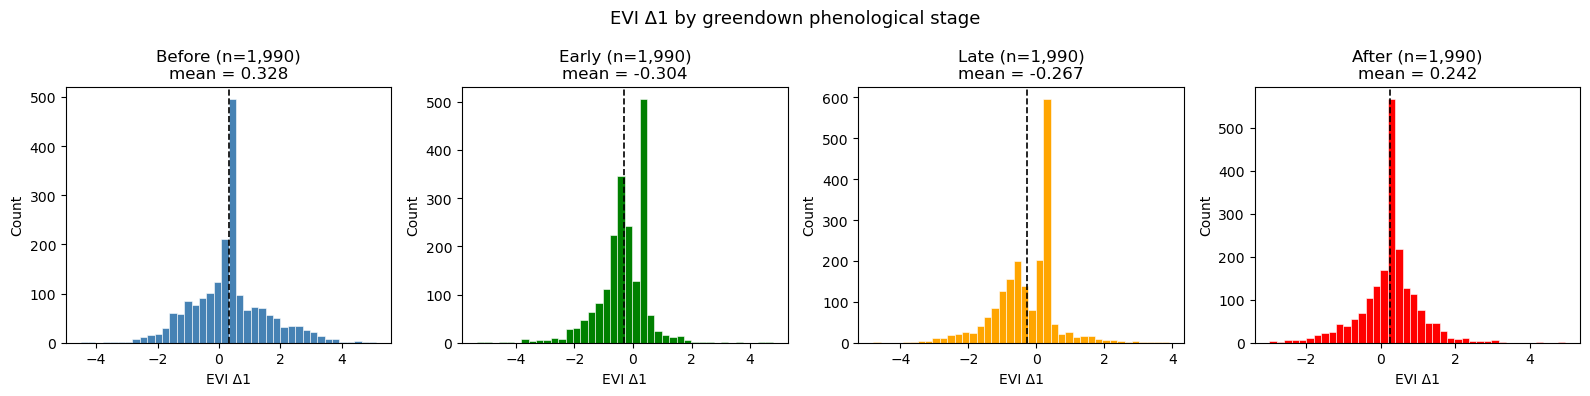

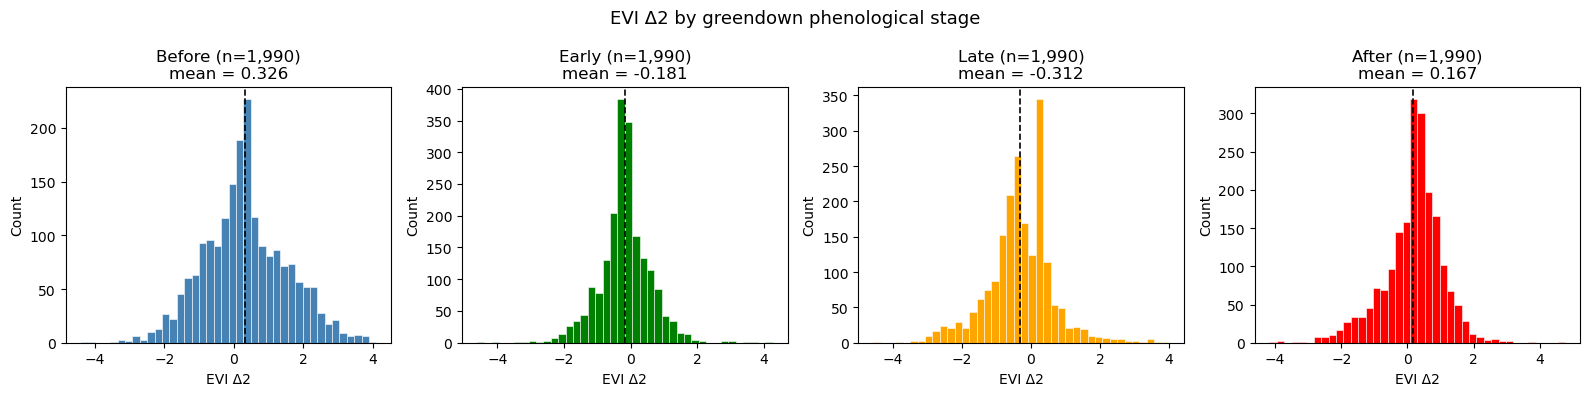

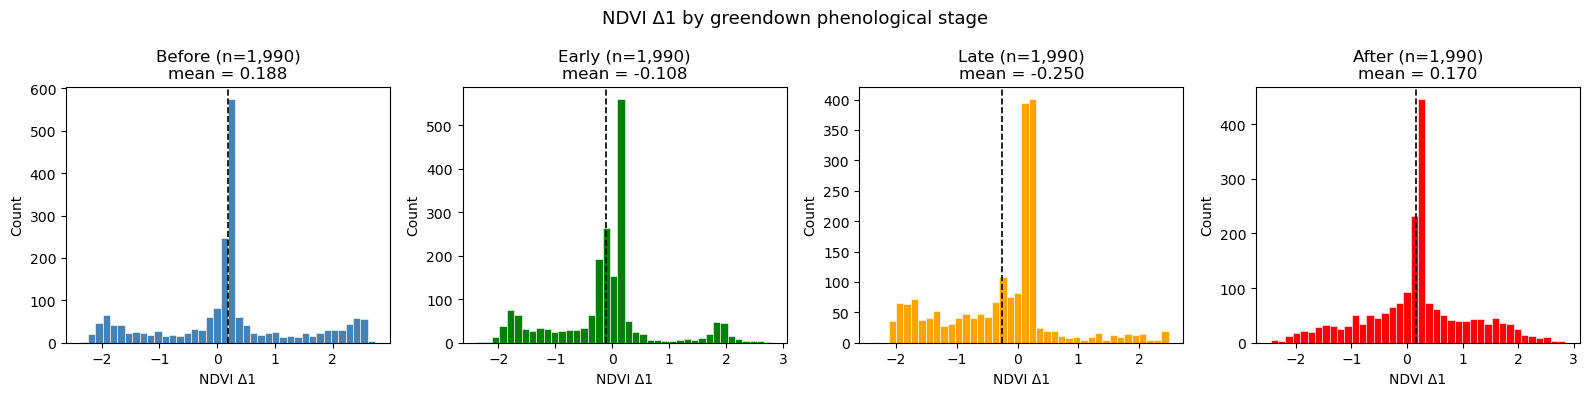

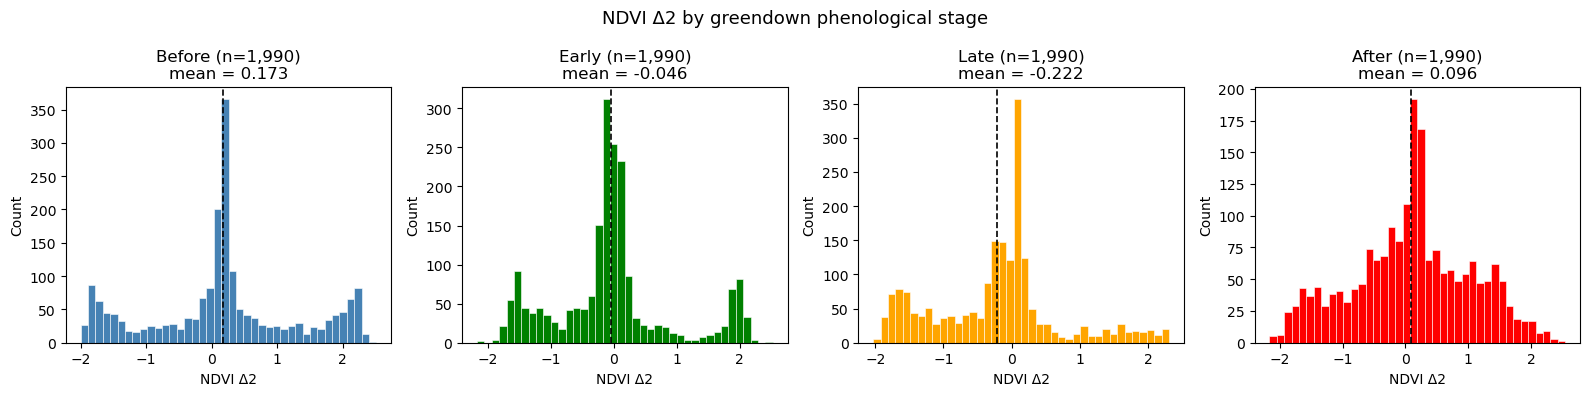

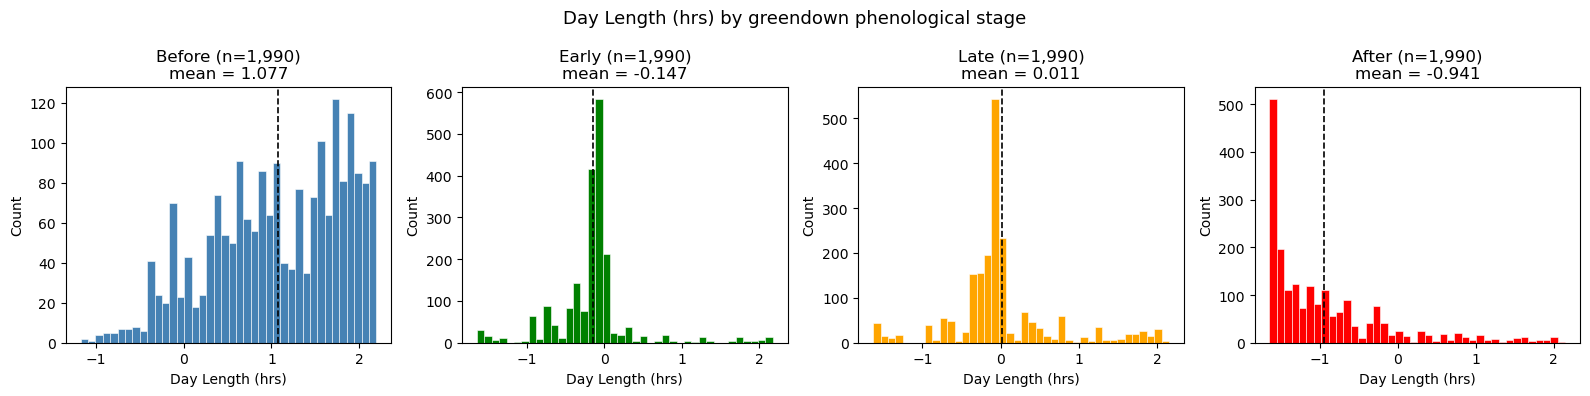

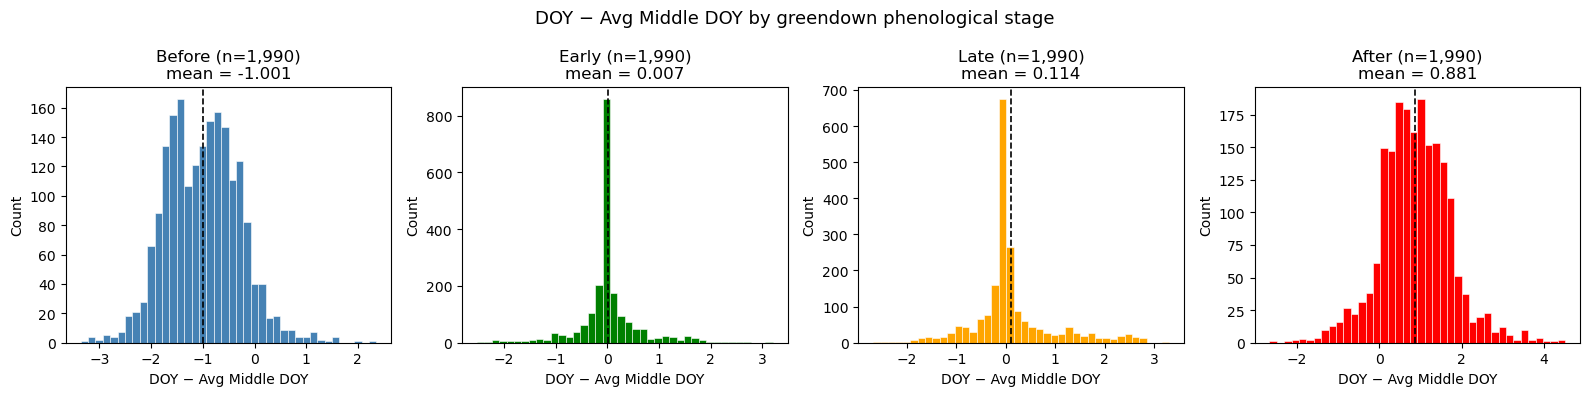

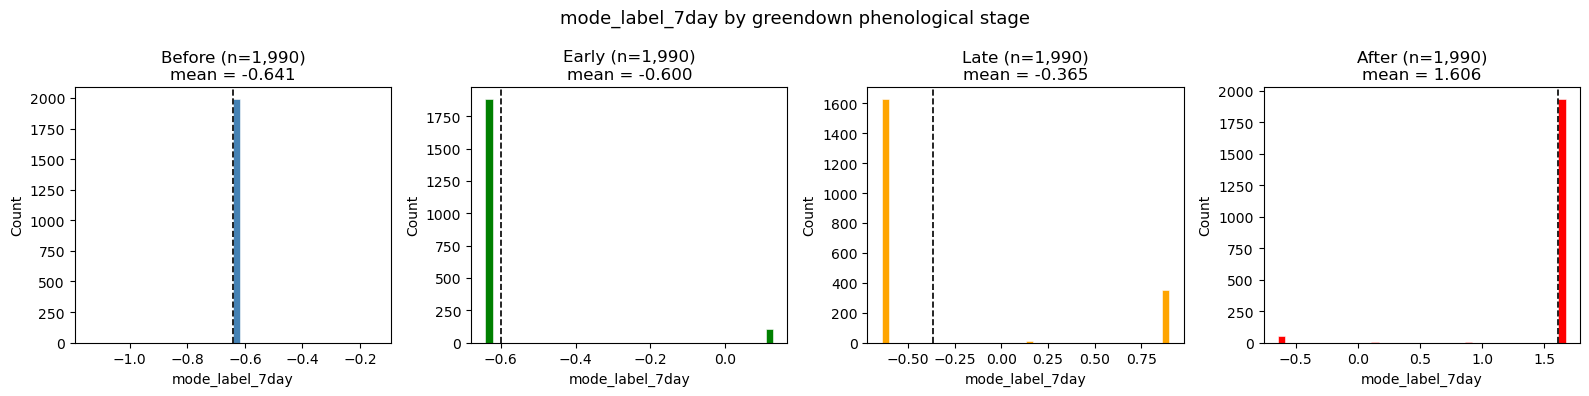

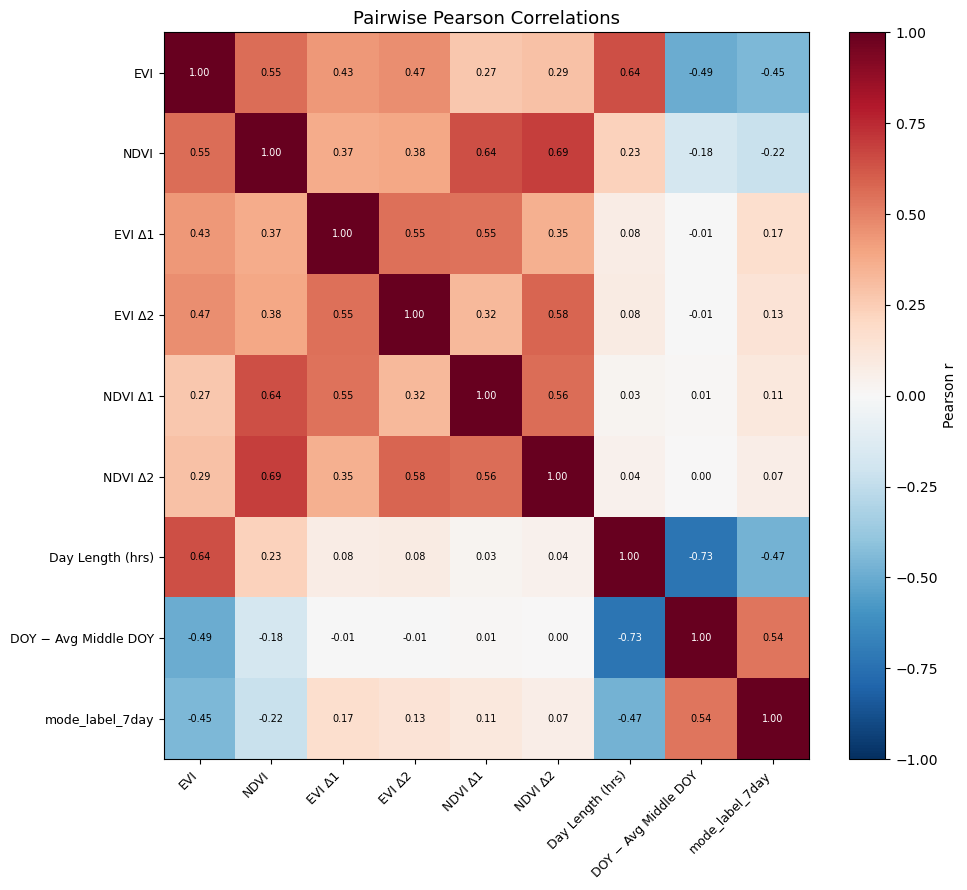

In [20]:
# ----------------------------
# Download gridMET cold degree-days for training years (stored locally).
# Skips any year whose gridmet_cdd_{year}.npz is already cached.
# Must be run before build_feature_table so the cdd_accumulated feature
# can be populated. Re-running is safe — cached years are skipped.
# ----------------------------
print('\nDownloading gridMET CDD for training years...')
training_years = list(range(start_year, train_year + 1))
for y in training_years:
    fetch_gridmet_cdd_historical(y, route_buffer, DATA_DIR)

# ----------------------------
# Build labeled EVI/NDVI feature table (training years only: 2013–2024)
# ----------------------------
print('\nBuilding labeled feature table...')
feature_df = build_feature_table(DATA_DIR, GREENDOWN_DIR, training_years)
print('\nEdited feature dataframe head before editing:')
print(feature_df.head())
print('\nNaN counts per column:')
#NaNs are present for delta columns at the start (these will be dropped)
print(feature_df.isna().sum())
plot_feature_distributions(feature_df) 
#Dropping DOY - Avg Start DOY and DOY - Avg End DOY because strongly correlated with eachother and DOY - Avg Middle DOY

feature_df_edited = edit_feature_table(feature_df, GREENDOWN_DIR, MODEL_DIR)
print('\nEdited feature dataframe head after editing:')
print(feature_df_edited.head())
print('\nNaN counts per column after editing:')
print(feature_df_edited.isna().sum())
plot_feature_distributions(feature_df_edited)


Model saved to ./Model_Outputs/decision_tree_model_no_pruning.joblib.joblib


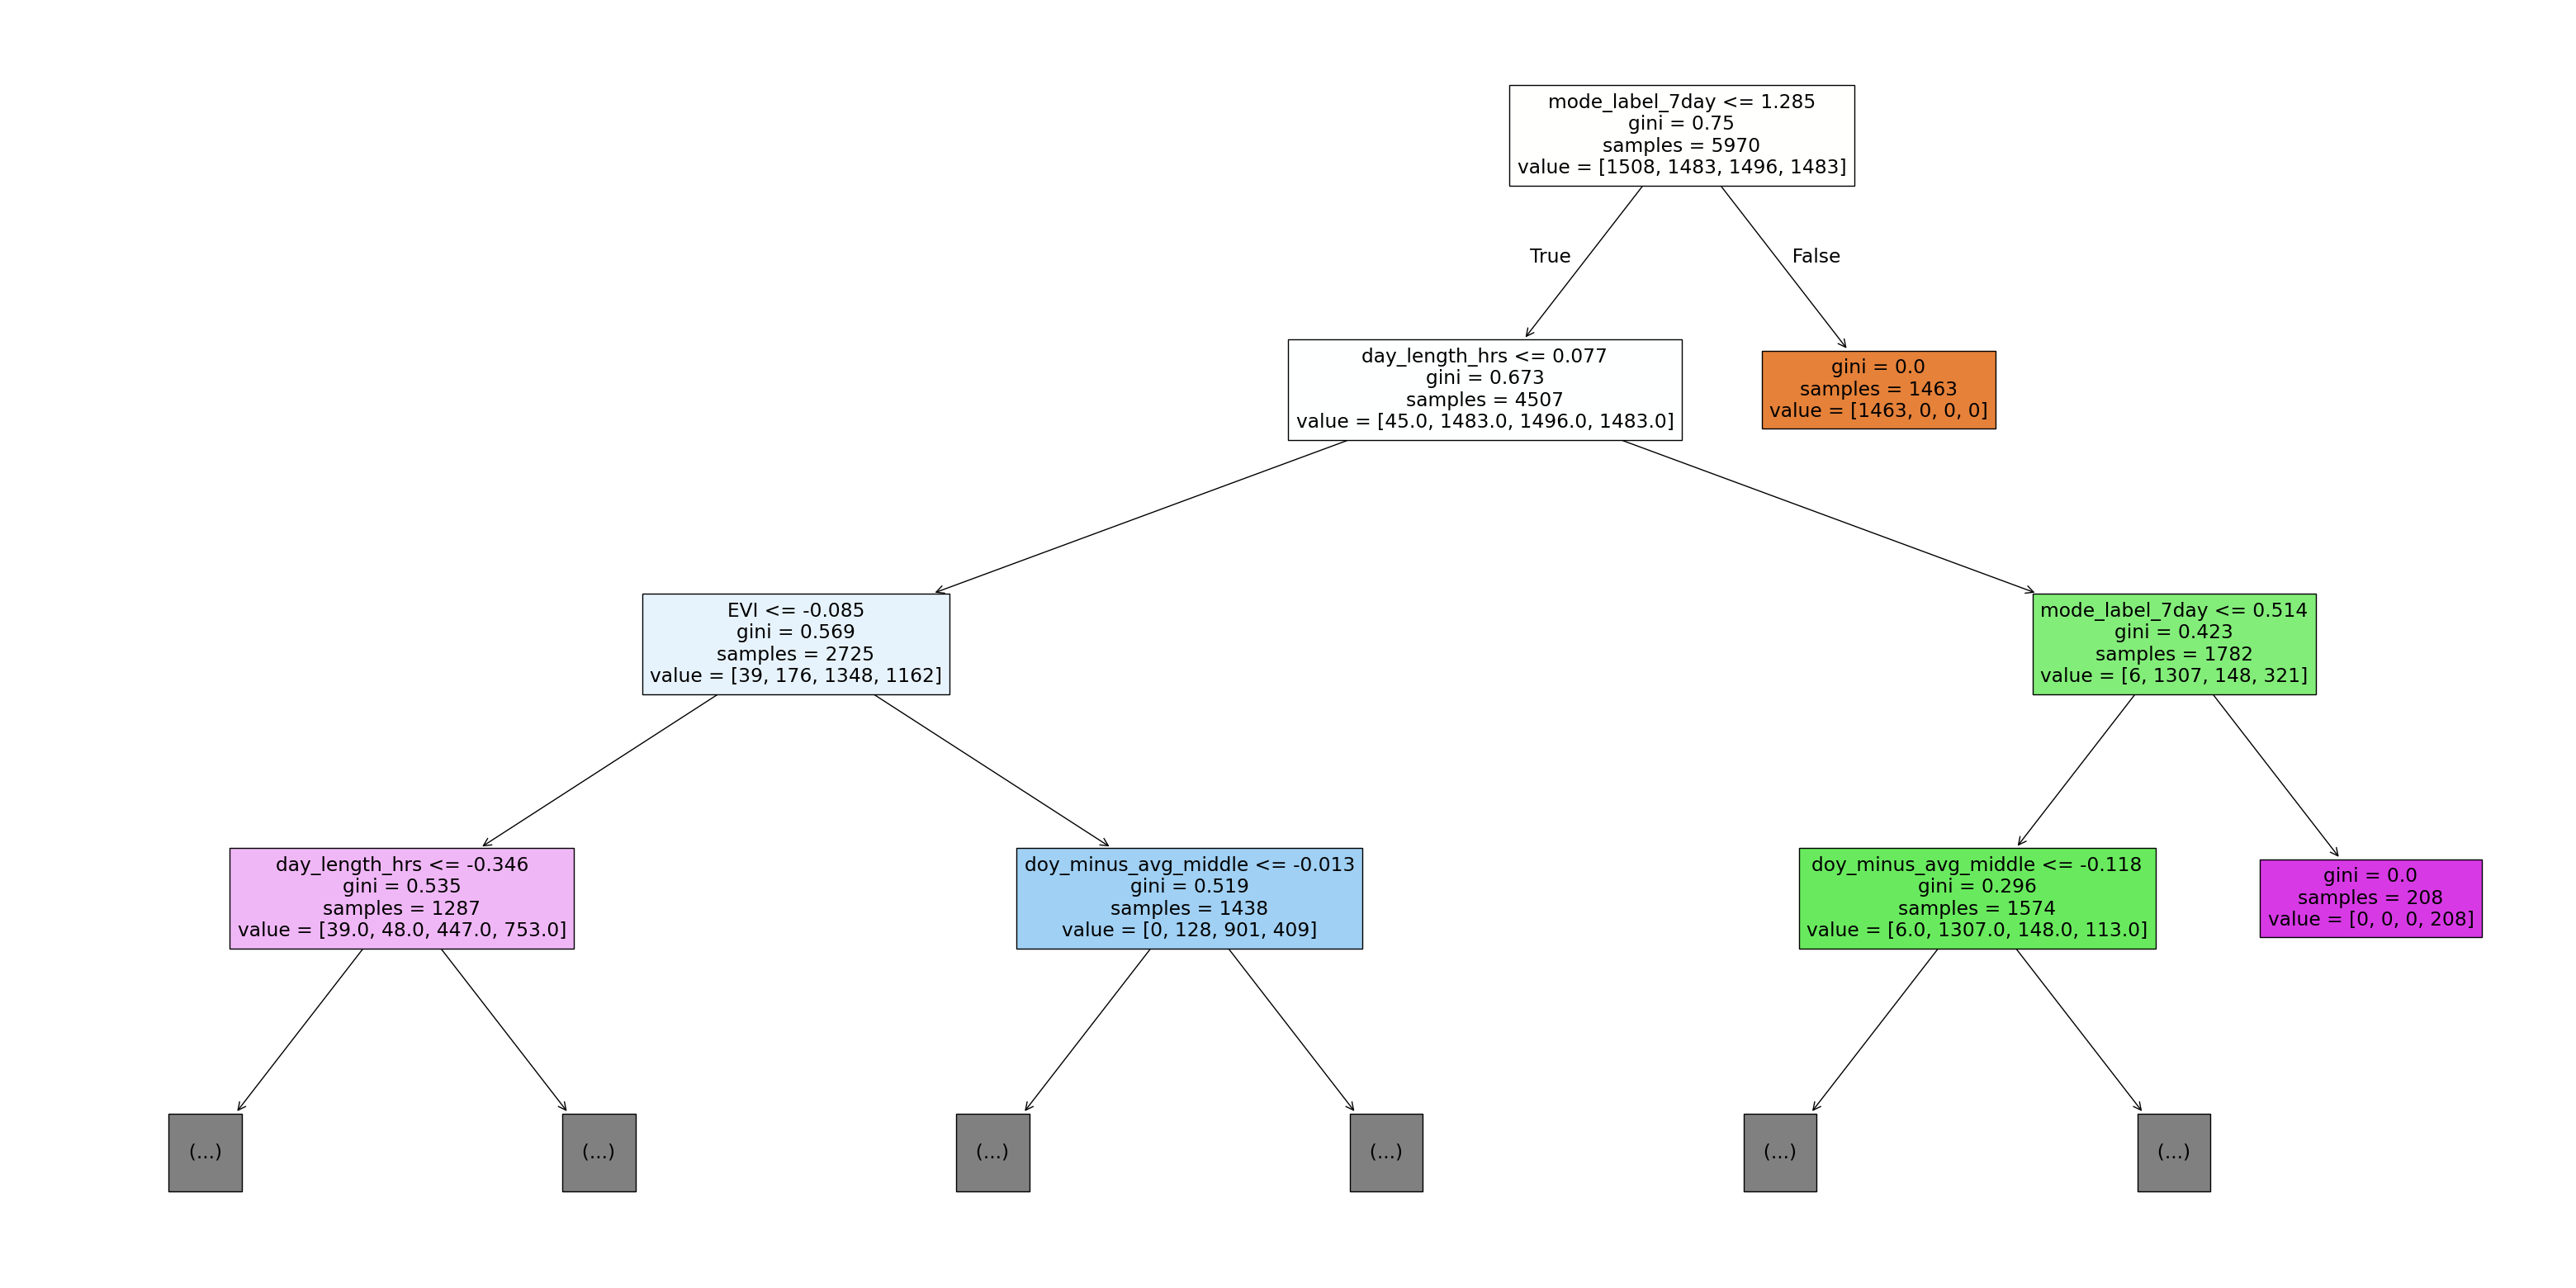

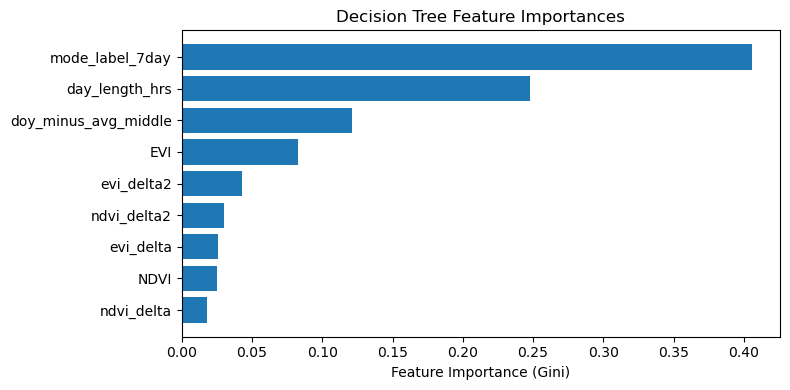


Test Accuracy Score:
0.864321608040201
              precision    recall  f1-score   support

       after       0.99      0.99      0.99       482
      before       0.90      0.89      0.90       507
       early       0.76      0.77      0.77       494
        late       0.81      0.81      0.81       507

    accuracy                           0.86      1990
   macro avg       0.87      0.87      0.87      1990
weighted avg       0.86      0.86      0.86      1990


Train Accuracy Score:
1.0
              precision    recall  f1-score   support

       after       1.00      1.00      1.00      1508
      before       1.00      1.00      1.00      1483
       early       1.00      1.00      1.00      1496
        late       1.00      1.00      1.00      1483

    accuracy                           1.00      5970
   macro avg       1.00      1.00      1.00      5970
weighted avg       1.00      1.00      1.00      5970



In [21]:
#Decision tree no pruning
# ----------------------------
# Build decision tree
# ----------------------------
x_train, x_test, y_train, y_test = split_data(feature_df_edited)
filename_ext = "_no_pruning"
filename = f'decision_tree_model{filename_ext}.joblib'

if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl, training_time_sec = fit_tree(x_train, y_train, False)

    # Save model for dashboard use
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    print(f'Model saved to {MODEL_DIR}/{filename}.joblib')
    with open(os.path.join(MODEL_DIR, f'training_time{filename_ext}.txt'), 'w') as f:
        f.write(f'{training_time_sec:.2f} seconds\n')
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))
    with open(os.path.join(MODEL_DIR, f'training_time{filename_ext}.txt')) as f:
        training_time_sec = float(f.read().split()[0])

plot_decision_tree(mdl, x_train, MODEL_DIR)

evaluate_decision_tree(mdl, x_test, y_test, x_train, y_train)

#Take-away: without pruning the accuracy on the training data is 1 and the accuracy on the testing data in 0.86 so the model is overfitting

Model saved to ./Model_Outputs/decision_tree_model_pruned.joblib.joblib


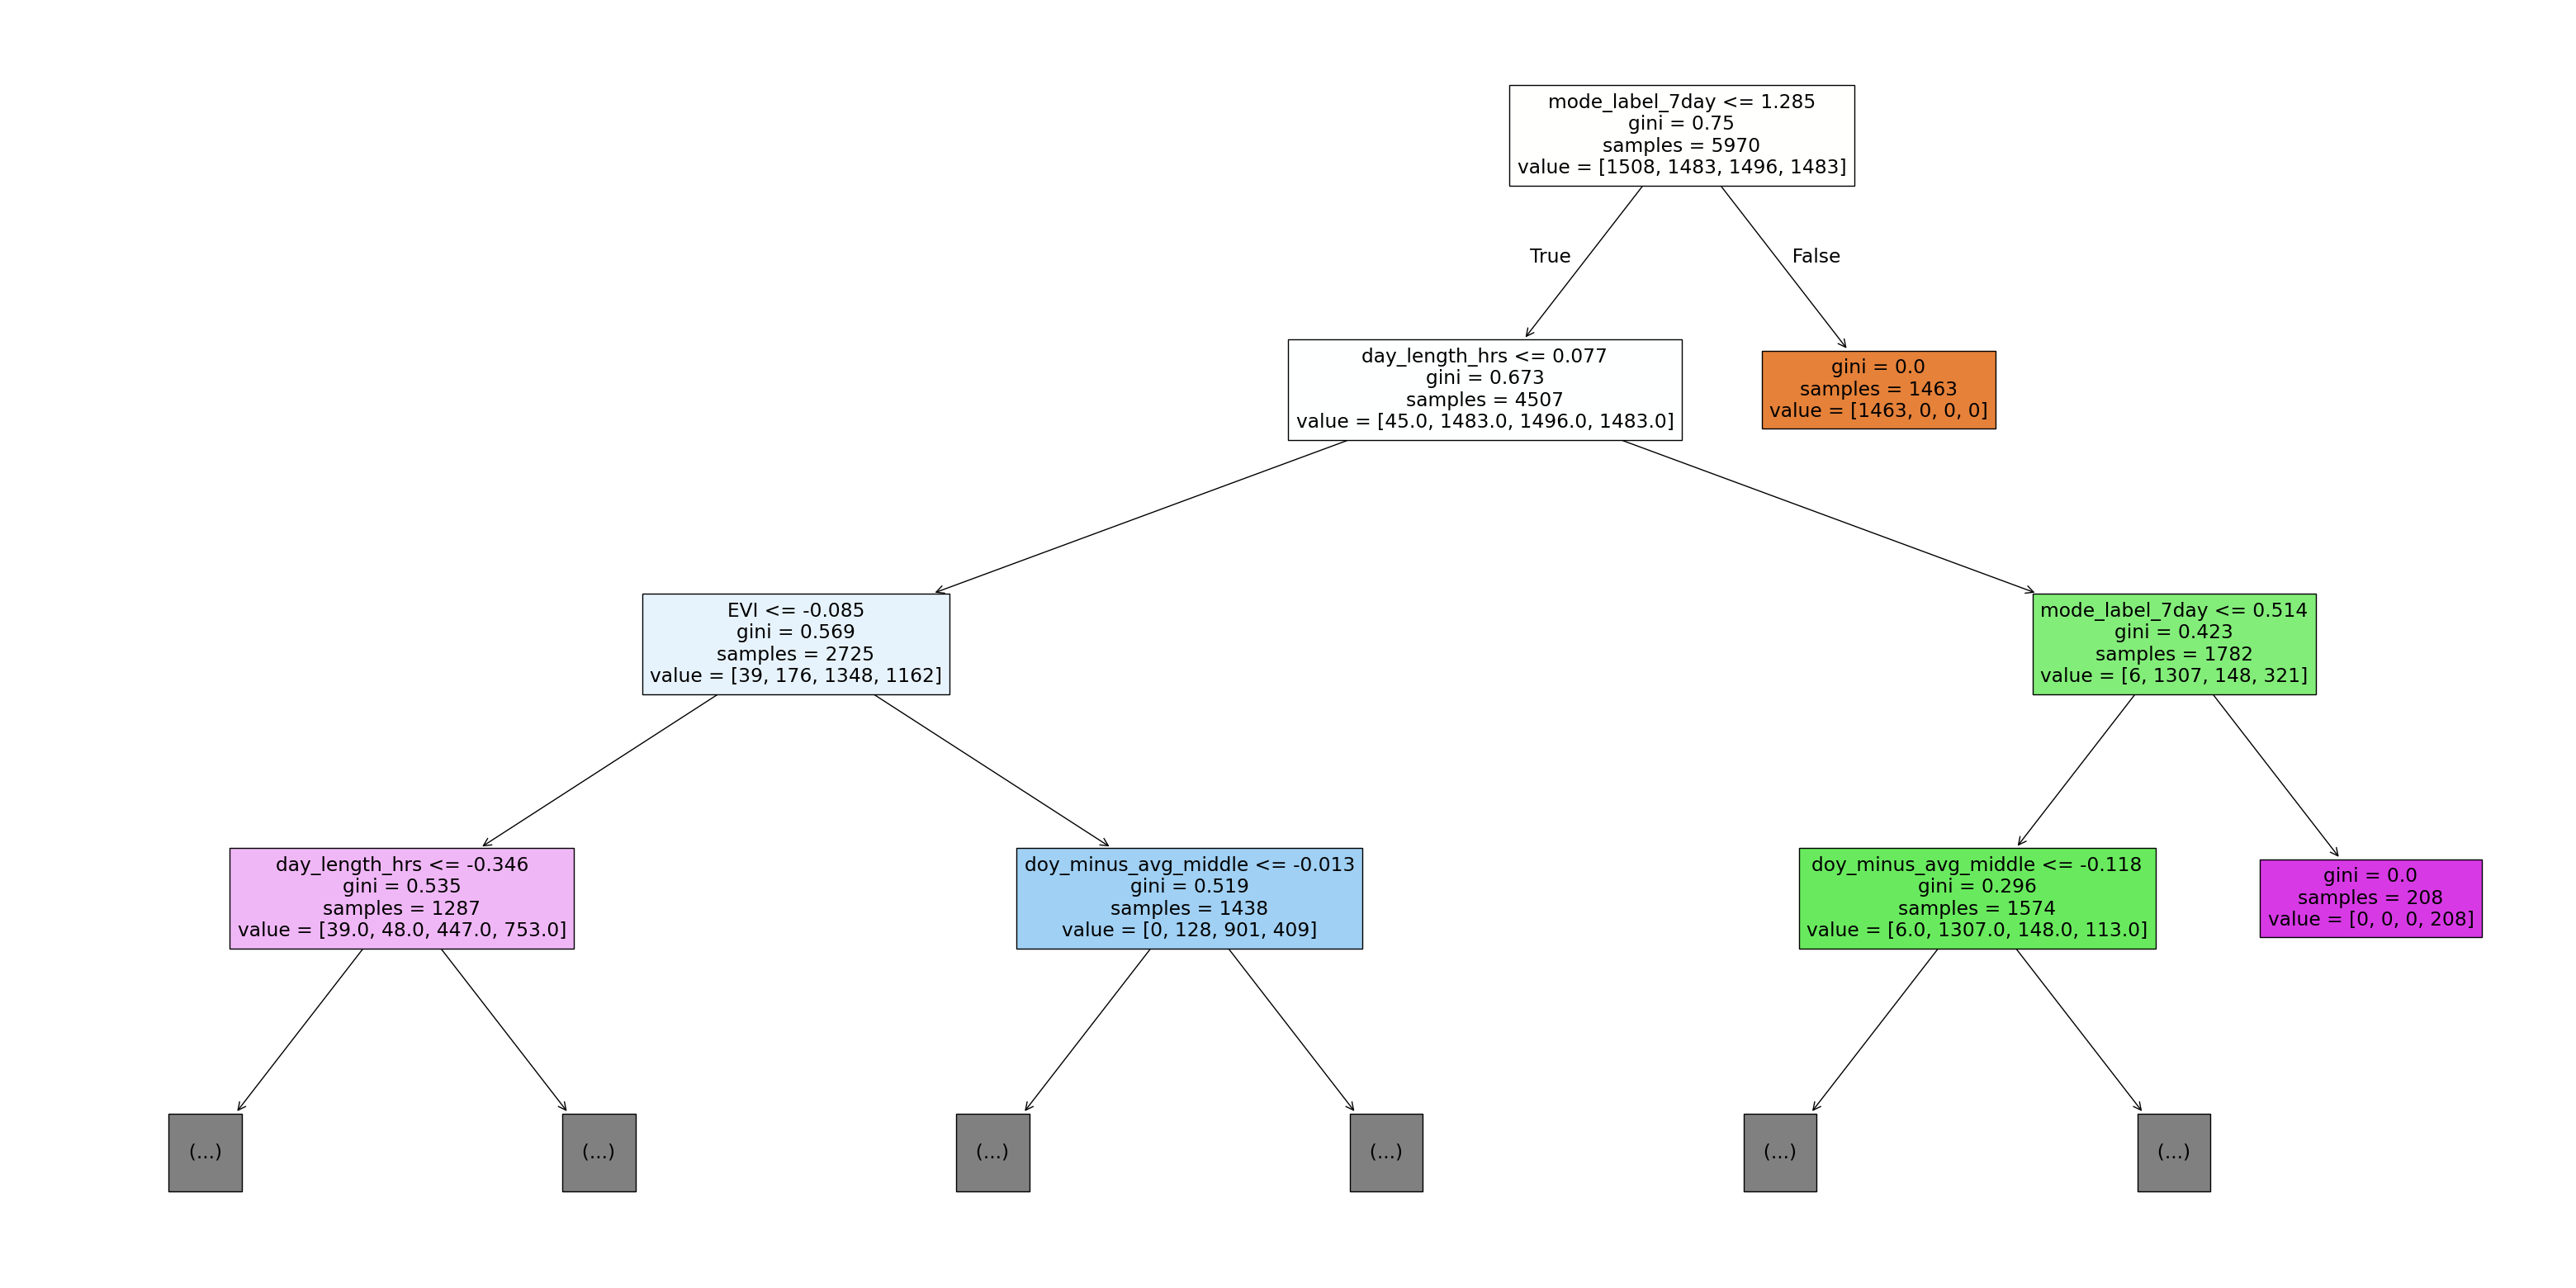

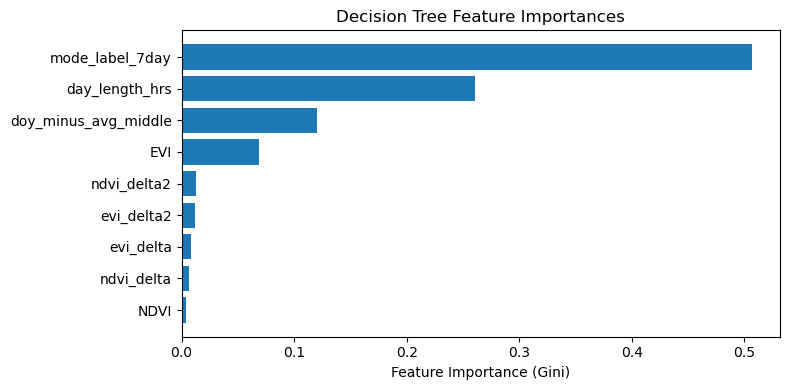


Test Accuracy Score:
0.8603015075376884
              precision    recall  f1-score   support

       after       0.98      0.98      0.98       482
      before       0.88      0.90      0.89       507
       early       0.76      0.80      0.78       494
        late       0.83      0.76      0.79       507

    accuracy                           0.86      1990
   macro avg       0.86      0.86      0.86      1990
weighted avg       0.86      0.86      0.86      1990


Train Accuracy Score:
0.8688442211055276
              precision    recall  f1-score   support

       after       0.99      0.99      0.99      1508
      before       0.87      0.92      0.89      1483
       early       0.78      0.81      0.79      1496
        late       0.84      0.76      0.80      1483

    accuracy                           0.87      5970
   macro avg       0.87      0.87      0.87      5970
weighted avg       0.87      0.87      0.87      5970



In [22]:
#Decision tree with pruning
# ----------------------------
# Build decision tree
# ----------------------------
x_train, x_test, y_train, y_test = split_data(feature_df_edited)

filename_ext = "_pruned"
filename = f'decision_tree_model{filename_ext}.joblib'
if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl = fit_tree(x_train, y_train, True)

    # Save model for dashboard use
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    joblib.dump(mdl, os.path.join(MODEL_DIR, 'decision_tree_model.joblib')) #save as current best model
    print(f'Model saved to {MODEL_DIR}/{filename}.joblib')
    with open(os.path.join(MODEL_DIR, f'training_time{filename_ext}.txt'), 'w') as f:
        f.write(f'{training_time_sec:.2f} seconds\n')
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))
    with open(os.path.join(MODEL_DIR, f'training_time{filename_ext}.txt')) as f:
        training_time_sec = float(f.read().split()[0])

plot_decision_tree(mdl, x_train, MODEL_DIR)

evaluate_decision_tree(mdl, x_test, y_test, x_train, y_train)

#Training and test accuracies are close so model is better even if the test accuracy went down a little


In [ ]:
#Feature selection

In [34]:
#Prepare Data for RNN
# ----------------------------
# RNN Training
# Builds a separate feature table with pixel_id and temperature features
# retained, reshapes into per-pixel-year sequences, trains an LSTM model,
# and saves rnn_model.pt + rnn_norm_stats.json + rnn_model_config.json.
# The decision tree (Cell 1) is unchanged; the website continues to use it.
# ----------------------------

# Rebuild feature table with pixel_id retained and temperature features enabled.
# Reuses already-downloaded HLS stacks and gridMET cache — no new GEE calls.
print('Building RNN feature table (with pixel_id + temperature)...')
rnn_df = build_feature_table(DATA_DIR, GREENDOWN_DIR, training_years,
                              retain_pixel_id=True,
                              include_temperature=True)
n_pixels = rnn_df['pixel_id'].nunique()
print(f'  {len(rnn_df)} observations across {n_pixels} unique pixels')
print(f'  NaN counts:\n{rnn_df[RNN_FEATURE_COLS].isna().sum().to_string()}')

# Reshape into per-pixel-year sequences (one sequence per pixel per year)
sequences = build_rnn_sequences(rnn_df)
seq_lens  = [len(s[0]) for s in sequences]
print(f'\n  {len(sequences)} sequences  |  '
      f'length range: {min(seq_lens)}–{max(seq_lens)}  |  '
      f'median: {int(sorted(seq_lens)[len(seq_lens)//2])}')

# Compute normalization stats and normalize in-place.
# normalize_sequences replaces any remaining NaN with 0.0 (= feature mean
# in z-score space), so NaN in temperature features cannot reach the LSTM.
norm_stats = compute_rnn_norm_stats(sequences)
normalize_sequences(sequences, norm_stats)
nan_check = sum(np.isnan(f).any() for f, _ in sequences)
print(f'  Sequences with NaN after normalization: {nan_check}  (must be 0)')

# Three-way split: 70% train / 15% val / 15% test.
# Test set is held out entirely until final evaluation — val drives early stopping.
# split_sequences splits by pixel-year so no pixel leaks across splits.
trainval_seqs, test_seqs  = split_sequences(sequences,     val_frac=0.15, seed=42)
train_seqs,    val_seqs   = split_sequences(trainval_seqs, val_frac=0.176, seed=42)
# 0.176 × 85% ≈ 15% of total
print(f'  Train: {len(train_seqs)}  |  Val: {len(val_seqs)}  |  Test: {len(test_seqs)} sequences')

device = 'cuda' if torch.cuda.is_available() else 'cpu'


Building RNN feature table (with pixel_id + temperature)...
  2013: 615 qualifying pixels
  2014: 236 qualifying pixels
  2015: 405 qualifying pixels
  2016: 284 qualifying pixels
  2017: 178 qualifying pixels
  2018: 921 qualifying pixels
  2019: 157 qualifying pixels
  2020: 157 qualifying pixels
  2021: 432 qualifying pixels
  2022: 431 qualifying pixels
  2023: 489 qualifying pixels
  2024: 438 qualifying pixels

Total labeled phenology observations: 120478
  120478 observations across 4072 unique pixels
  NaN counts:
EVI                        0
NDVI                       0
evi_delta               4743
evi_delta2              9486
ndvi_delta              4743
ndvi_delta2             9486
day_length_hrs             0
doy_minus_avg_middle       0
tmean_recent               0

  4743 sequences  |  length range: 11–76  |  median: 19
  Sequences with NaN after normalization: 0  (must be 0)
  Train: 3323  |  Val: 709  |  Test: 711 sequences


  Epoch   1/60  train_loss=0.7560  val_loss=0.4297  val_acc=0.8917
  Epoch  10/60  train_loss=0.2679  val_loss=0.2679  val_acc=0.9214
  Epoch  20/60  train_loss=0.2088  val_loss=0.2265  val_acc=0.9355
  Epoch  30/60  train_loss=0.1773  val_loss=0.2044  val_acc=0.9410
  Epoch  40/60  train_loss=0.1532  val_loss=0.1886  val_acc=0.9450
  Epoch  50/60  train_loss=0.1342  val_loss=0.1852  val_acc=0.9472
  Epoch  60/60  train_loss=0.1188  val_loss=0.1810  val_acc=0.9497
  Training time: 3.1 min
  Saved rnn_model_dropout_only.pt + rnn_norm_stats_dropout_only.json + rnn_model_config_dropout_only.json + rnn_history_dropout_only.json → ./Model_Outputs

Validation results:
              precision    recall  f1-score   support

      before       0.95      0.98      0.97      9992
       early       0.61      0.55      0.58       309
        late       0.75      0.58      0.65       476
       after       0.97      0.95      0.96      7667

    accuracy                           0.95     18444
   

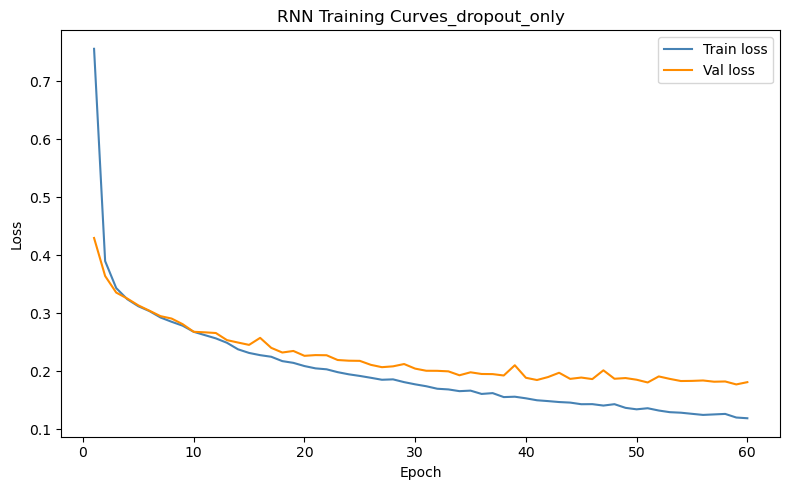

In [30]:
#Build model with dropout only
#Claude added dropout as a default
filename_ext = "_dropout_only"
filename = f'rnn_model{filename_ext}.pt'

if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    model = RNNPhenologyModel(input_size=len(RNN_FEATURE_COLS), hidden_size=64, num_layers=2)
    model, history, training_time_sec = train_rnn(model, train_seqs, val_seqs,
                  epochs=60, lr=1e-3, batch_size=64, device=device) #Claude suggested 60 as original epochs number
    # Save
    save_rnn_model(model, norm_stats, MODEL_DIR, history, training_time_sec, filename_ext)
else:
    model, norm_stats, history = load_rnn_model(MODEL_DIR,filename_ext)
    training_time_sec = history['training_time_sec']

# ----------------------------
# Evaluate: val, test, and train (train last to check for overfitting)
# ----------------------------
print('\nValidation results:')
evaluate_rnn(model, val_seqs, device=device)

print('\nTest results:')
evaluate_rnn(model, test_seqs, device=device)

print('\nTrain results (compare to test to check overfitting):')
evaluate_rnn(model, train_seqs, device=device)

print("\n Training time (seconds)")
print(training_time_sec)

plot_rnn_training_curves(history, filename_ext, MODEL_DIR)
#Big difference in model performance between classes. 
#Worst for the early and late phenological states, which makes sense since they have the smaller percentage of data

  After oversampling: 59600 training sequences
  Epoch   1/60  train_loss=0.2312  val_loss=0.3140  val_acc=0.9179
  Epoch  10/60  train_loss=0.0277  val_loss=0.2908  val_acc=0.9353
  Epoch  20/60  train_loss=0.0154  val_loss=0.3123  val_acc=0.9467
  Epoch  30/60  train_loss=0.0117  val_loss=0.3722  val_acc=0.9472
  Epoch  40/60  train_loss=0.0096  val_loss=0.3509  val_acc=0.9483
  Epoch  50/60  train_loss=0.0097  val_loss=0.3680  val_acc=0.9488
  Epoch  60/60  train_loss=0.0076  val_loss=0.4032  val_acc=0.9517
  Training time: 70.8 min
  Saved rnn_model_class_balancing.pt + rnn_norm_stats_class_balancing.json + rnn_model_config_class_balancing.json + rnn_history_class_balancing.json → ./Model_Outputs
  Saved rnn_model.pt + rnn_norm_stats.json + rnn_model_config.json + rnn_history.json → ./Model_Outputs

Validation results:
              precision    recall  f1-score   support

      before       0.96      0.98      0.97      9992
       early       0.57      0.59      0.58       309
  

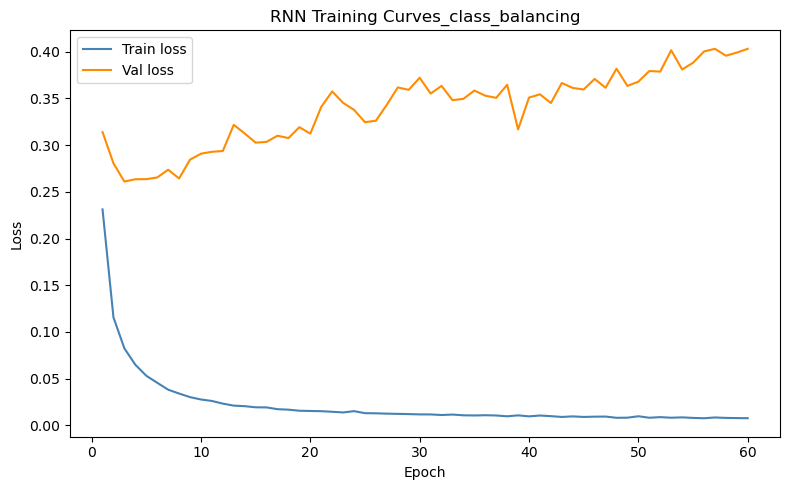

In [32]:
#Build model with class balancing

# Oversample minority-class sequences in the training set only.
# target_ratio=1.0 fully balances all classes to the majority count.
# Lower (e.g. 0.5) if you see overfitting on the val classification report.
train_seqs_rebalanced = oversample_sequences(train_seqs, target_ratio=1.0)
print(f'  After oversampling: {len(train_seqs_rebalanced)} training sequences')

filename_ext = "_class_balancing"
filename = f'rnn_model{filename_ext}.pt'

if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    model = RNNPhenologyModel(input_size=len(RNN_FEATURE_COLS), hidden_size=64, num_layers=2)
    model, history, training_time_sec = train_rnn(model, train_seqs_rebalanced, val_seqs,
                  epochs=60, lr=1e-3, batch_size=64, device=device) #Claude suggested 60 as original epochs number
    # Save
    save_rnn_model(model, norm_stats, MODEL_DIR, history, training_time_sec, filename_ext)
    save_rnn_model(model, norm_stats, MODEL_DIR,"") #Save as current best RNN model
else:
    model, norm_stats, history = load_rnn_model(MODEL_DIR,filename_ext)
    training_time_sec = history['training_time_sec']

# ----------------------------
# Evaluate: val, test, and train (train last to check for overfitting)
# ----------------------------
print('\nValidation results:')
evaluate_rnn(model, val_seqs, device=device)

print('\nTest results:')
evaluate_rnn(model, test_seqs, device=device)

print('\nTrain results (compare to test to check overfitting):')
evaluate_rnn(model, train_seqs_rebalanced, device=device)

print("\n Training time (seconds)")
print(training_time_sec)

plot_rnn_training_curves(history, filename_ext, MODEL_DIR)
#The class rebalancing did not really help improve the performance of the early and late phenological states as expected

#Even though the overall accuracy is pretty high  (0.9987 for training) the loss curves show that it is overfitting now. 
#Implementing early stopping probably won't help the overfitting problem because the validation never seems to be close to the training

  Epoch   1/60  train_loss=0.2223  val_loss=0.3145  val_acc=0.9180
  Epoch  10/60  train_loss=0.0265  val_loss=0.2749  val_acc=0.9429
  Early stopping at epoch 15 (no val_loss improvement for 10 epochs)
  Training time: 17.5 min
  Saved rnn_model_early_stopping.pt + rnn_norm_stats_early_stopping.json + rnn_model_config_early_stopping.json + rnn_history_early_stopping.json → ./Model_Outputs

Validation results:
              precision    recall  f1-score   support

      before       0.94      0.98      0.96      9992
       early       0.56      0.69      0.62       309
        late       0.61      0.62      0.61       476
       after       0.98      0.92      0.95      7667

    accuracy                           0.94     18444
   macro avg       0.77      0.80      0.78     18444
weighted avg       0.94      0.94      0.94     18444

Overall accuracy: 0.9403

Test results:
              precision    recall  f1-score   support

      before       0.94      0.98      0.96      9562
  

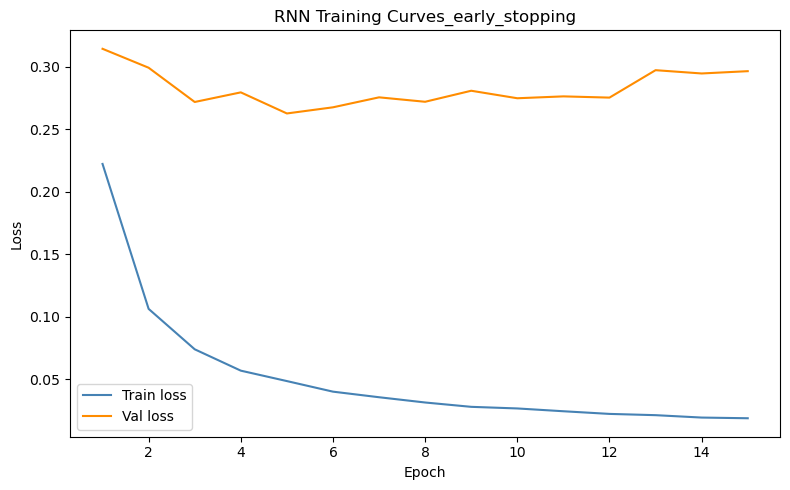

  Epoch   1/60  train_loss=0.0406  val_loss=0.2769  val_acc=0.9399
  Epoch  10/60  train_loss=0.0181  val_loss=0.3075  val_acc=0.9414
  Early stopping at epoch 13 (no val_loss improvement for 10 epochs)
  Training time: 14.8 min


In [35]:
#Early stopping (improve speed)
filename_ext = "_early_stopping"
filename = f'rnn_model{filename_ext}.pt'

if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    model = RNNPhenologyModel(input_size=len(RNN_FEATURE_COLS), hidden_size=64, num_layers=2)
    model, history, training_time_sec = train_rnn(model, train_seqs_rebalanced, val_seqs,
        epochs=60, lr=1e-3, batch_size=64, device=device,
        early_stopping=True, patience=10)
    # Save
    save_rnn_model(model, norm_stats, MODEL_DIR, history, training_time_sec, filename_ext)
    #save_rnn_model(model, norm_stats, MODEL_DIR,"") #Save as current best RNN model
else:
    model, norm_stats, history = load_rnn_model(MODEL_DIR,filename_ext)
    training_time_sec = history['training_time_sec']

# ----------------------------
# Evaluate: val, test, and train (train last to check for overfitting)
# ----------------------------
print('\nValidation results:')
evaluate_rnn(model, val_seqs, device=device)

print('\nTest results:')
evaluate_rnn(model, test_seqs, device=device)

print('\nTrain results (compare to test to check overfitting):')
evaluate_rnn(model, train_seqs_rebalanced, device=device)

print("\n Training time (seconds)")
print(training_time_sec)

plot_rnn_training_curves(history, filename_ext, MODEL_DIR)


  Epoch   1/100  train_loss=1.1049  val_loss=0.4451  val_acc=0.8863
  Epoch  10/100  train_loss=0.3837  val_loss=0.3082  val_acc=0.9112
  Epoch  20/100  train_loss=0.3347  val_loss=0.2813  val_acc=0.9201
  Epoch  30/100  train_loss=0.3068  val_loss=0.2705  val_acc=0.9225
  Epoch  40/100  train_loss=0.2920  val_loss=0.2473  val_acc=0.9280
  Epoch  50/100  train_loss=0.2790  val_loss=0.2380  val_acc=0.9300
  Epoch  60/100  train_loss=0.2694  val_loss=0.2354  val_acc=0.9309
  Epoch  70/100  train_loss=0.2625  val_loss=0.2336  val_acc=0.9314
  Epoch  80/100  train_loss=0.2581  val_loss=0.2296  val_acc=0.9313
  Epoch  90/100  train_loss=0.2535  val_loss=0.2245  val_acc=0.9346
  Epoch 100/100  train_loss=0.2465  val_loss=0.2237  val_acc=0.9351
  Training time: 6.6 min
  Saved rnn_model_L1R.pt + rnn_norm_stats_L1R.json + rnn_model_config_L1R.json + rnn_history_L1R.json → ./Model_Outputs

Validation results:
              precision    recall  f1-score   support

      before       0.94      0.

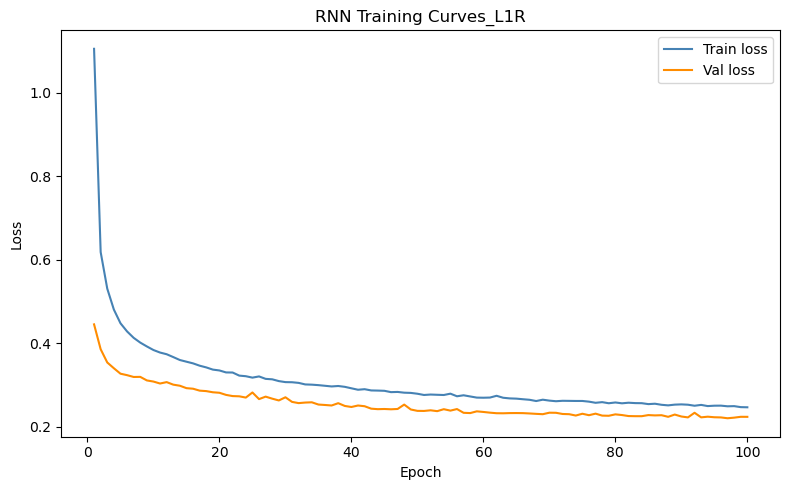

In [39]:
#L1 regularization
#Using L1 because it drops features and the decision tree shows that some features really don't matter
filename_ext = "_L1R"
filename = f'rnn_model{filename_ext}.pt'

if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    model = RNNPhenologyModel(input_size=len(RNN_FEATURE_COLS), hidden_size=64, num_layers=2)
    model, history, training_time_sec = train_rnn(model, train_seqs, val_seqs, epochs=100, lr=1e-3,
                                                  batch_size=64, device='cpu', early_stopping=True,
                                                  patience=10, L1_regular=True, l1_lambda=1e-4)
    # Save
    save_rnn_model(model, norm_stats, MODEL_DIR, history, training_time_sec, filename_ext)
    #save_rnn_model(model, norm_stats, MODEL_DIR,"") #Save as current best RNN model
else:
    model, norm_stats, history = load_rnn_model(MODEL_DIR,filename_ext)
    training_time_sec = history['training_time_sec']

# ----------------------------
# Evaluate: val, test, and train (train last to check for overfitting)
# ----------------------------
print('\nValidation results:')
evaluate_rnn(model, val_seqs, device=device)

print('\nTest results:')
evaluate_rnn(model, test_seqs, device=device)

print('\nTrain results (compare to test to check overfitting):')
evaluate_rnn(model, train_seqs_rebalanced, device=device)

print("\n Training time (seconds)")
print(training_time_sec)

plot_rnn_training_curves(history, filename_ext, MODEL_DIR)

In [ ]:
#Use soft labels